# 📋 PROMPT 1: IMPORT & KHÁM PHÁ DỮ LIỆU PCB

**Mục tiêu**: Import và trích xuất dữ liệu từ 3 bộ dataset PCB defect detection.  
**Mục tiêu cuối cùng**: NHẬN DẠNG và KHOANH VÙNG các lỗi trên bo mạch PCB.

## 1. Import thư viện cần thiết

In [17]:
import os
import glob
import shutil
import random
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Seed để tái tạo kết quả
random.seed(42)
np.random.seed(42)

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


## 2. Định nghĩa đường dẫn 3 bộ dữ liệu

In [18]:
# ============================================================
# Đường dẫn gốc của project
# ============================================================
ROOT = Path('E:\Machine Learning\Deep Learning\project\DEEP\DEEP')

# Thông tin 3 bộ dữ liệu
DATASETS = {
    'HRIPCB_UPDATE': {
        'path': ROOT / 'HRIPCB_UPDATE',
        'splits': {
            'train': 'train',
            'val': 'val',
            'test': 'test',
        },
    },
    'DeepPCB': {
        'path': ROOT / 'DeepPCB',
        'splits': {
            'train': 'train',
            'val': 'valid',     # thư mục tên 'valid'
            'test': 'test',
        },
    },
    'DsPCBSD+': {
        'path': ROOT / 'PCB.v1i.yolov8',
        'splits': {
            'train': 'train',
            'val': 'valid',     # thư mục tên 'valid'
            # KHÔNG có tập test → sẽ tách từ train ở bước sau
        },
    },
}

# Kiểm tra thư mục tồn tại
for name, info in DATASETS.items():
    exists = info['path'].exists()
    print(f"{'✅' if exists else '❌'} {name}: {info['path']}")

✅ HRIPCB_UPDATE: E:\Machine Learning\Deep Learning\project\DEEP\DEEP\HRIPCB_UPDATE
✅ DeepPCB: E:\Machine Learning\Deep Learning\project\DEEP\DEEP\DeepPCB
✅ DsPCBSD+: E:\Machine Learning\Deep Learning\project\DEEP\DEEP\PCB.v1i.yolov8


## 3. Đọc file `data.yaml` của từng dataset

In [19]:
# ============================================================
# Đọc và hiển thị thông tin từ data.yaml
# ============================================================
for name, info in DATASETS.items():
    yaml_path = info['path'] / 'data.yaml'
    print(f"\n{'='*60}")
    print(f"📁 Dataset: {name}")
    print(f"{'='*60}")
    
    if yaml_path.exists():
        with open(yaml_path, 'r', encoding='utf-8') as f:
            data_cfg = yaml.safe_load(f)
        
        # Lưu config vào dict
        info['config'] = data_cfg
        
        # Số class
        nc = data_cfg.get('nc', 'N/A')
        print(f"  Số class (nc): {nc}")
        
        # Tên class
        names = data_cfg.get('names', [])
        if isinstance(names, dict):
            # Format: {0: 'name1', 1: 'name2', ...}
            info['class_names'] = names
            print(f"  Tên class:")
            for idx, cls_name in names.items():
                print(f"    {idx}: {cls_name}")
        elif isinstance(names, list):
            # Format: ['name1', 'name2', ...]
            info['class_names'] = {i: n for i, n in enumerate(names)}
            print(f"  Tên class:")
            for i, cls_name in enumerate(names):
                print(f"    {i}: {cls_name}")
        
        # Đường dẫn train/val/test trong yaml
        for split_name in ['train', 'val', 'test']:
            split_path = data_cfg.get(split_name, 'Không có')
            print(f"  {split_name}: {split_path}")
    else:
        print(f"  ⚠️ Không tìm thấy file data.yaml!")


📁 Dataset: HRIPCB_UPDATE
  Số class (nc): 6
  Tên class:
    0: Missing_hole
    1: Mouse_bite
    2: Open_circuit
    3: Short
    4: Spurious_copper
    5: Spur
  train: /kaggle/input/hripcb-dataset/HRIPCB_UPDATE/train
  val: /kaggle/input/hripcb-dataset/HRIPCB_UPDATE/val
  test: /kaggle/input/hripcb-dataset/HRIPCB_UPDATE/test

📁 Dataset: DeepPCB
  ⚠️ Không tìm thấy file data.yaml!

📁 Dataset: DsPCBSD+
  Số class (nc): 9
  Tên class:
    0: 0
    1: 1
    2: 2
    3: 3
    4: 4
    5: 5
    6: 6
    7: 7
    8: 8
  train: ../train/images
  val: ../valid/images
  test: ../test/images


## 4. Thống kê số lượng ảnh

In [20]:
# ============================================================
# Hàm đếm số ảnh và label trong một thư mục
# ============================================================
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def dem_file(folder, loai='images'):
    """Đếm số file ảnh hoặc label trong thư mục."""
    folder = Path(folder)
    if not folder.exists():
        return 0
    if loai == 'images':
        return sum(1 for f in folder.iterdir() 
                   if f.is_file() and f.suffix.lower() in IMG_EXTENSIONS)
    else:  # labels
        return sum(1 for f in folder.iterdir() 
                   if f.is_file() and f.suffix.lower() == '.txt')

# ============================================================
# Thống kê số lượng ảnh và label cho mỗi dataset
# ============================================================
thongke_rows = []

for name, info in DATASETS.items():
    base = info['path']
    row = {'Dataset': name}
    
    for split_key, split_dir in info['splits'].items():
        img_dir = base / split_dir / 'images'
        lbl_dir = base / split_dir / 'labels'
        
        n_img = dem_file(img_dir, 'images')
        n_lbl = dem_file(lbl_dir, 'labels')
        
        row[f'{split_key}_img'] = n_img
        row[f'{split_key}_lbl'] = n_lbl
    
    # Nếu không có test
    if 'test' not in info['splits']:
        row['test_img'] = 0
        row['test_lbl'] = 0
    
    # Tổng
    row['tong_img'] = sum(v for k, v in row.items() 
                          if k.endswith('_img') and isinstance(v, int))
    row['tong_lbl'] = sum(v for k, v in row.items() 
                          if k.endswith('_lbl') and isinstance(v, int))
    
    thongke_rows.append(row)

# Tạo bảng hiển thị
df_thongke = pd.DataFrame(thongke_rows)
df_thongke.columns = ['Dataset', 
                       'Train (ảnh)', 'Train (label)',
                       'Val (ảnh)', 'Val (label)',
                       'Test (ảnh)', 'Test (label)',
                       'Tổng ảnh', 'Tổng label']

print('\n📊 BẢNG THỐNG KÊ SỐ LƯỢNG ẢNH & LABEL')
print('='*80)
display(df_thongke.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]))


📊 BẢNG THỐNG KÊ SỐ LƯỢNG ẢNH & LABEL


,Dataset,Train (ảnh),Train (label),Val (ảnh),Val (label),Test (ảnh),Test (label),Tổng ảnh,Tổng label
0,HRIPCB_UPDATE,485,485,138,138,70,70,693,693
1,DeepPCB,1200,1200,150,150,150,150,1500,1500
2,DsPCBSD+,19698,19698,1642,1642,0,0,21340,21340


## 4b. Tách 10% train thành test (cho dataset thiếu test)

In [21]:
# ============================================================
# Tách 10% dữ liệu train → test cho dataset KHÔNG có tập test
# ============================================================
def tach_test_tu_train(dataset_path, train_dir='train', test_dir='test', 
                        ty_le=0.1, seed=42):
    """
    Tách 10% dữ liệu train thành tập test.
    Copy file (không di chuyển) để giữ nguyên dữ liệu gốc.
    """
    base = Path(dataset_path)
    train_img = base / train_dir / 'images'
    train_lbl = base / train_dir / 'labels'
    test_img = base / test_dir / 'images'
    test_lbl = base / test_dir / 'labels'
    
    # Kiểm tra nếu test đã tồn tại
    if test_img.exists() and len(list(test_img.iterdir())) > 0:
        n = len([f for f in test_img.iterdir() if f.is_file()])
        print(f"  ⚠️ Thư mục test đã tồn tại với {n} ảnh. Bỏ qua.")
        return n
    
    # Tạo thư mục test
    test_img.mkdir(parents=True, exist_ok=True)
    test_lbl.mkdir(parents=True, exist_ok=True)
    
    # Lấy danh sách ảnh train
    all_images = sorted([f for f in train_img.iterdir() 
                         if f.is_file() and f.suffix.lower() in IMG_EXTENSIONS])
    
    # Random chọn 10%
    random.seed(seed)
    n_test = max(1, int(len(all_images) * ty_le))
    test_images = random.sample(all_images, n_test)
    
    # Copy ảnh và label sang test
    count = 0
    for img_file in test_images:
        # Copy ảnh
        shutil.copy2(img_file, test_img / img_file.name)
        
        # Copy label tương ứng
        lbl_file = train_lbl / (img_file.stem + '.txt')
        if lbl_file.exists():
            shutil.copy2(lbl_file, test_lbl / lbl_file.name)
        
        count += 1
    
    print(f"  ✅ Đã tách {count} ảnh từ train → test ({ty_le*100:.0f}%)")
    return count

# Áp dụng cho các dataset thiếu test
for name, info in DATASETS.items():
    if 'test' not in info['splits']:
        print(f"\n📦 Dataset: {name} - KHÔNG có tập test")
        n = tach_test_tu_train(
            info['path'],
            train_dir=info['splits']['train'],
            test_dir='test',
            ty_le=0.1
        )
        # Cập nhật splits
        info['splits']['test'] = 'test'
        print(f"  → Đã cập nhật: test = {n} ảnh")
    else:
        print(f"\n✅ Dataset: {name} - Đã có tập test")

print("\n" + "="*60)
print("🎉 Hoàn tất kiểm tra và tách tập test!")


✅ Dataset: HRIPCB_UPDATE - Đã có tập test

✅ Dataset: DeepPCB - Đã có tập test

📦 Dataset: DsPCBSD+ - KHÔNG có tập test
  ✅ Đã tách 1969 ảnh từ train → test (10%)
  → Đã cập nhật: test = 1969 ảnh

🎉 Hoàn tất kiểm tra và tách tập test!


## 5. Phân tích phân bố nhãn (Label Distribution)

In [22]:
# ============================================================
# Hàm đọc và đếm nhãn từ file label YOLO
# ============================================================
def doc_va_dem_nhan(label_dir):
    """
    Đọc tất cả file .txt trong thư mục label,
    đếm số bounding box theo class_id.
    """
    label_dir = Path(label_dir)
    counter = Counter()
    tong_box = 0
    tong_file = 0
    
    if not label_dir.exists():
        return counter, 0, 0
    
    for txt_file in sorted(label_dir.glob('*.txt')):
        tong_file += 1
        with open(txt_file, 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    parts = line.split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        counter[class_id] += 1
                        tong_box += 1
    
    return counter, tong_box, tong_file

# ============================================================
# Thống kê phân bố nhãn cho tất cả dataset
# ============================================================
phan_bo_data = {}  # {dataset_name: {split: Counter}}

for name, info in DATASETS.items():
    print(f"\n{'='*60}")
    print(f"📁 Dataset: {name}")
    print(f"{'='*60}")
    
    class_names = info.get('class_names', {})
    phan_bo_data[name] = {}
    
    for split_key, split_dir in info['splits'].items():
        lbl_dir = info['path'] / split_dir / 'labels'
        counter, tong_box, tong_file = doc_va_dem_nhan(lbl_dir)
        phan_bo_data[name][split_key] = counter
        
        print(f"\n  📂 {split_key.upper()}: {tong_file} file, {tong_box} bounding boxes")
        for cls_id in sorted(counter.keys()):
            cls_name = class_names.get(cls_id, f'class_{cls_id}')
            print(f"    [{cls_id}] {cls_name}: {counter[cls_id]} boxes")


📁 Dataset: HRIPCB_UPDATE

  📂 TRAIN: 485 file, 2060 bounding boxes
    [0] Missing_hole: 410 boxes
    [1] Mouse_bite: 314 boxes
    [2] Open_circuit: 355 boxes
    [3] Short: 327 boxes
    [4] Spurious_copper: 345 boxes
    [5] Spur: 309 boxes

  📂 VAL: 138 file, 600 bounding boxes
    [0] Missing_hole: 54 boxes
    [1] Mouse_bite: 129 boxes
    [2] Open_circuit: 98 boxes
    [3] Short: 94 boxes
    [4] Spurious_copper: 118 boxes
    [5] Spur: 107 boxes

  📂 TEST: 70 file, 293 bounding boxes
    [0] Missing_hole: 33 boxes
    [1] Mouse_bite: 49 boxes
    [2] Open_circuit: 29 boxes
    [3] Short: 70 boxes
    [4] Spurious_copper: 40 boxes
    [5] Spur: 72 boxes

📁 Dataset: DeepPCB

  📂 TRAIN: 1200 file, 8024 bounding boxes
    [0] class_0: 5 boxes
    [1] class_1: 1 boxes
    [2] class_2: 2 boxes
    [3] class_3: 2 boxes
    [4] class_4: 5 boxes
    [5] class_5: 4 boxes
    [6] class_6: 1 boxes
    [7] class_7: 2 boxes
    [8] class_8: 4 boxes
    [9] class_9: 7 boxes
    [10] class_1

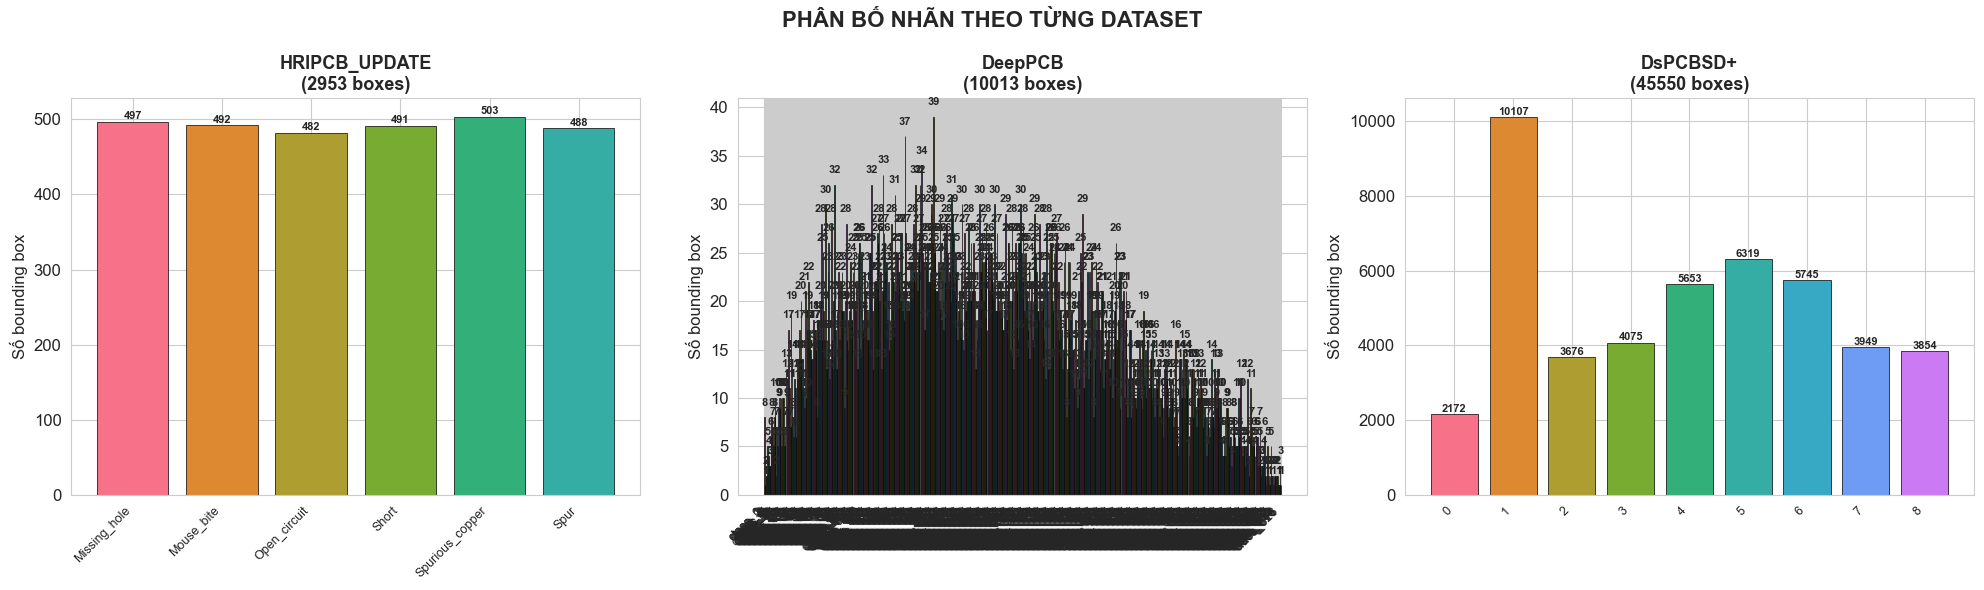


💾 Đã lưu biểu đồ: label_distribution.png


In [23]:
# ============================================================
# Vẽ biểu đồ phân bố nhãn cho mỗi dataset
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('PHÂN BỐ NHÃN THEO TỪNG DATASET', fontsize=16, fontweight='bold')

colors_palette = sns.color_palette('husl', 10)

for idx, (name, info) in enumerate(DATASETS.items()):
    ax = axes[idx]
    class_names = info.get('class_names', {})
    
    # Gộp tất cả splits
    total_counter = Counter()
    for split_key, counter in phan_bo_data[name].items():
        total_counter.update(counter)
    
    if not total_counter:
        ax.set_title(f'{name}\n(Không có dữ liệu)')
        continue
    
    # Tạo dữ liệu cho biểu đồ
    cls_ids = sorted(total_counter.keys())
    cls_labels = [class_names.get(cid, f'class_{cid}') for cid in cls_ids]
    counts = [total_counter[cid] for cid in cls_ids]
    
    bars = ax.bar(range(len(cls_ids)), counts, 
                  color=[colors_palette[i % len(colors_palette)] for i in range(len(cls_ids))],
                  edgecolor='black', linewidth=0.5)
    
    ax.set_xticks(range(len(cls_ids)))
    ax.set_xticklabels(cls_labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{name}\n({sum(counts)} boxes)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Số bounding box')
    
    # Ghi số lên mỗi cột
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                str(count), ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(str(ROOT / 'label_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\n💾 Đã lưu biểu đồ: label_distribution.png')

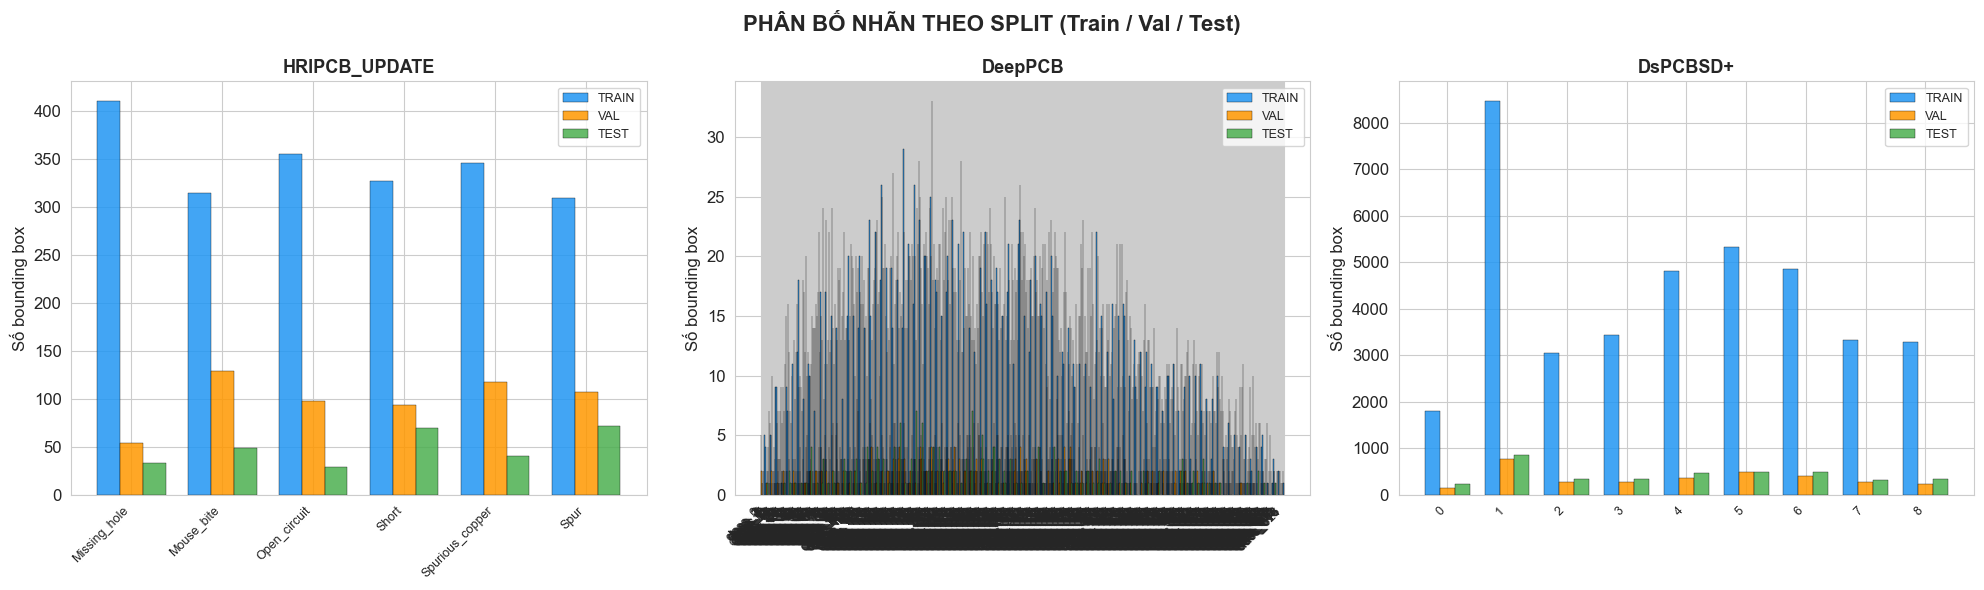

💾 Đã lưu biểu đồ: label_distribution_by_split.png


In [24]:
# ============================================================
# Vẽ biểu đồ stacked bar (Train/Val/Test) cho mỗi dataset
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('PHÂN BỐ NHÃN THEO SPLIT (Train / Val / Test)', fontsize=16, fontweight='bold')

split_colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

for idx, (name, info) in enumerate(DATASETS.items()):
    ax = axes[idx]
    class_names = info.get('class_names', {})
    
    # Thu thập dữ liệu theo split
    all_cls = set()
    for split_counter in phan_bo_data[name].values():
        all_cls.update(split_counter.keys())
    cls_ids = sorted(all_cls)
    cls_labels = [class_names.get(cid, f'class_{cid}') for cid in cls_ids]
    
    if not cls_ids:
        ax.set_title(f'{name}\n(Không có dữ liệu)')
        continue
    
    x = np.arange(len(cls_ids))
    width = 0.25
    
    for i, (split_key, color) in enumerate(split_colors.items()):
        if split_key in phan_bo_data[name]:
            values = [phan_bo_data[name][split_key].get(cid, 0) for cid in cls_ids]
            ax.bar(x + i*width, values, width, label=split_key.upper(), 
                   color=color, alpha=0.85, edgecolor='black', linewidth=0.3)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(cls_labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Số bounding box')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(ROOT / 'label_distribution_by_split.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu biểu đồ: label_distribution_by_split.png')

In [25]:
# ============================================================
# Nhận xét về sự mất cân bằng dữ liệu
# ============================================================
print('\n📝 PHÂN TÍCH SỰ MẤT CÂN BẰNG DỮ LIỆU (CLASS IMBALANCE)')
print('='*60)

for name, info in DATASETS.items():
    class_names = info.get('class_names', {})
    
    # Gộp tất cả splits
    total_counter = Counter()
    for split_counter in phan_bo_data[name].values():
        total_counter.update(split_counter)
    
    if not total_counter:
        continue
    
    counts = list(total_counter.values())
    max_count = max(counts)
    min_count = min(counts)
    ratio = max_count / min_count if min_count > 0 else float('inf')
    
    print(f"\n📁 {name}:")
    print(f"   Class nhiều nhất : {max_count} boxes")
    print(f"   Class ít nhất   : {min_count} boxes")
    print(f"   Tỷ lệ imbalance : {ratio:.2f}x")
    
    if ratio > 5:
        print(f"   ⚠️  MẤT CÂN BẰNG NGHIÊM TRỌNG → Cần augmentation/oversampling")
    elif ratio > 2:
        print(f"   ⚡ Mất cân bằng vừa phải → Nên xem xét class weights")
    else:
        print(f"   ✅ Dữ liệu tương đối cân bằng")


📝 PHÂN TÍCH SỰ MẤT CÂN BẰNG DỮ LIỆU (CLASS IMBALANCE)

📁 HRIPCB_UPDATE:
   Class nhiều nhất : 503 boxes
   Class ít nhất   : 482 boxes
   Tỷ lệ imbalance : 1.04x
   ✅ Dữ liệu tương đối cân bằng

📁 DeepPCB:
   Class nhiều nhất : 39 boxes
   Class ít nhất   : 1 boxes
   Tỷ lệ imbalance : 39.00x
   ⚠️  MẤT CÂN BẰNG NGHIÊM TRỌNG → Cần augmentation/oversampling

📁 DsPCBSD+:
   Class nhiều nhất : 10107 boxes
   Class ít nhất   : 2172 boxes
   Tỷ lệ imbalance : 4.65x
   ⚡ Mất cân bằng vừa phải → Nên xem xét class weights


## 6. Hiển thị ảnh mẫu kèm bounding box

In [26]:
# ============================================================
# Hàm vẽ bounding box lên ảnh
# ============================================================
# Bảng màu cho từng loại lỗi
COLORS_MAP = [
    (255, 0, 0),      # Đỏ
    (0, 255, 0),      # Xanh lá
    (0, 0, 255),      # Xanh dương
    (255, 255, 0),    # Vàng
    (255, 0, 255),    # Tím
    (0, 255, 255),    # Cyan
    (255, 128, 0),    # Cam
    (128, 0, 255),    # Tím đậm
    (0, 128, 255),    # Xanh nhạt
]

def ve_bbox_len_anh(img_path, label_path, class_names_dict):
    """
    Đọc ảnh và vẽ bounding box từ file label YOLO.
    Trả về ảnh đã vẽ (RGB).
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    label_path = Path(label_path)
    if not label_path.exists():
        return img
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                x_center, y_center, bw, bh = map(float, parts[1:5])
                
                # Chuyển từ YOLO format → pixel
                x1 = int((x_center - bw/2) * w)
                y1 = int((y_center - bh/2) * h)
                x2 = int((x_center + bw/2) * w)
                y2 = int((y_center + bh/2) * h)
                
                color = COLORS_MAP[cls_id % len(COLORS_MAP)]
                cls_name = class_names_dict.get(cls_id, f'class_{cls_id}')
                
                # Vẽ rectangle
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                
                # Vẽ ellipse (khoanh tròn) bao quanh lỗi
                cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
                rx, ry = (x2 - x1) // 2 + 5, (y2 - y1) // 2 + 5
                cv2.ellipse(img, (cx, cy), (rx, ry), 0, 0, 360, color, 2)
                
                # Ghi tên class
                label_text = f"{cls_name}"
                (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(img, (x1, y1 - th - 6), (x1 + tw, y1), color, -1)
                cv2.putText(img, label_text, (x1, y1 - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    return img

print('✅ Đã định nghĩa hàm vẽ bounding box!')

✅ Đã định nghĩa hàm vẽ bounding box!



🖼️  Ảnh mẫu từ dataset: HRIPCB_UPDATE


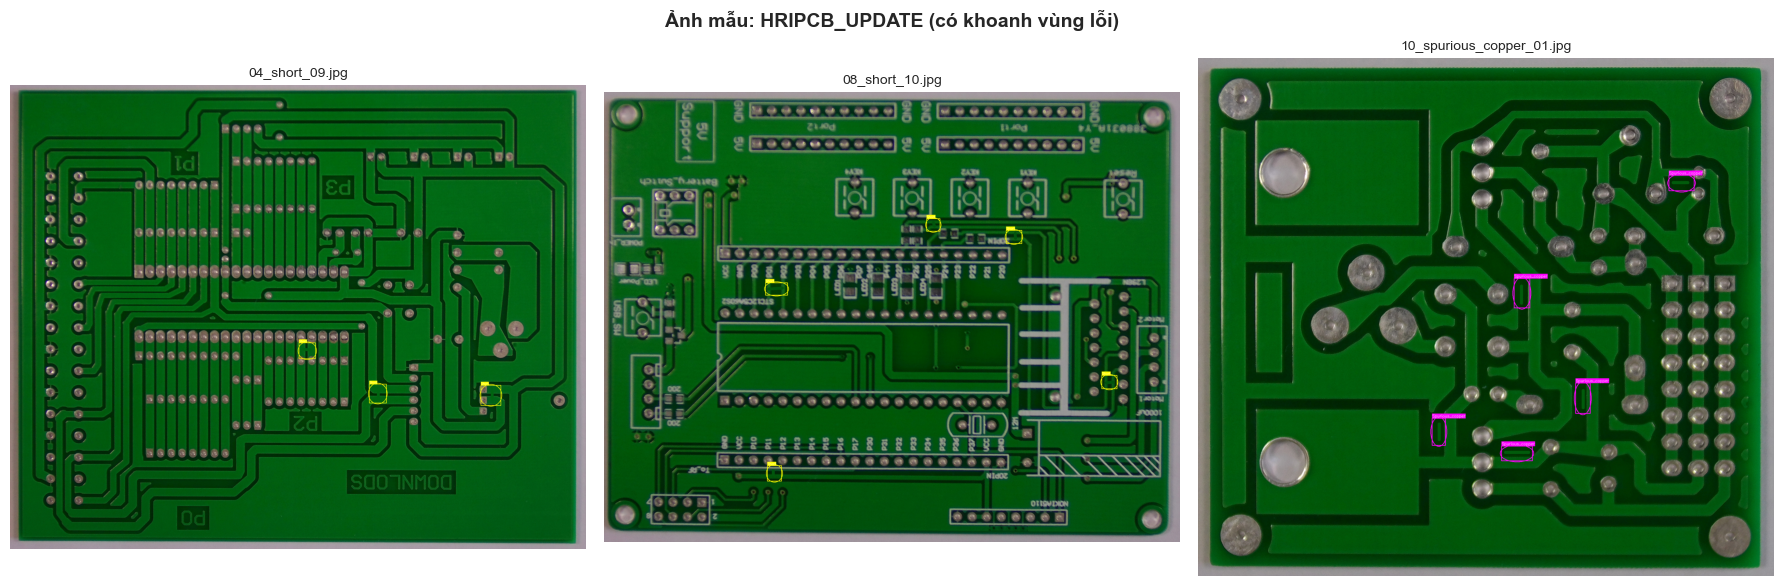

💾 Đã lưu: sample_HRIPCB_UPDATE.png

🖼️  Ảnh mẫu từ dataset: DeepPCB


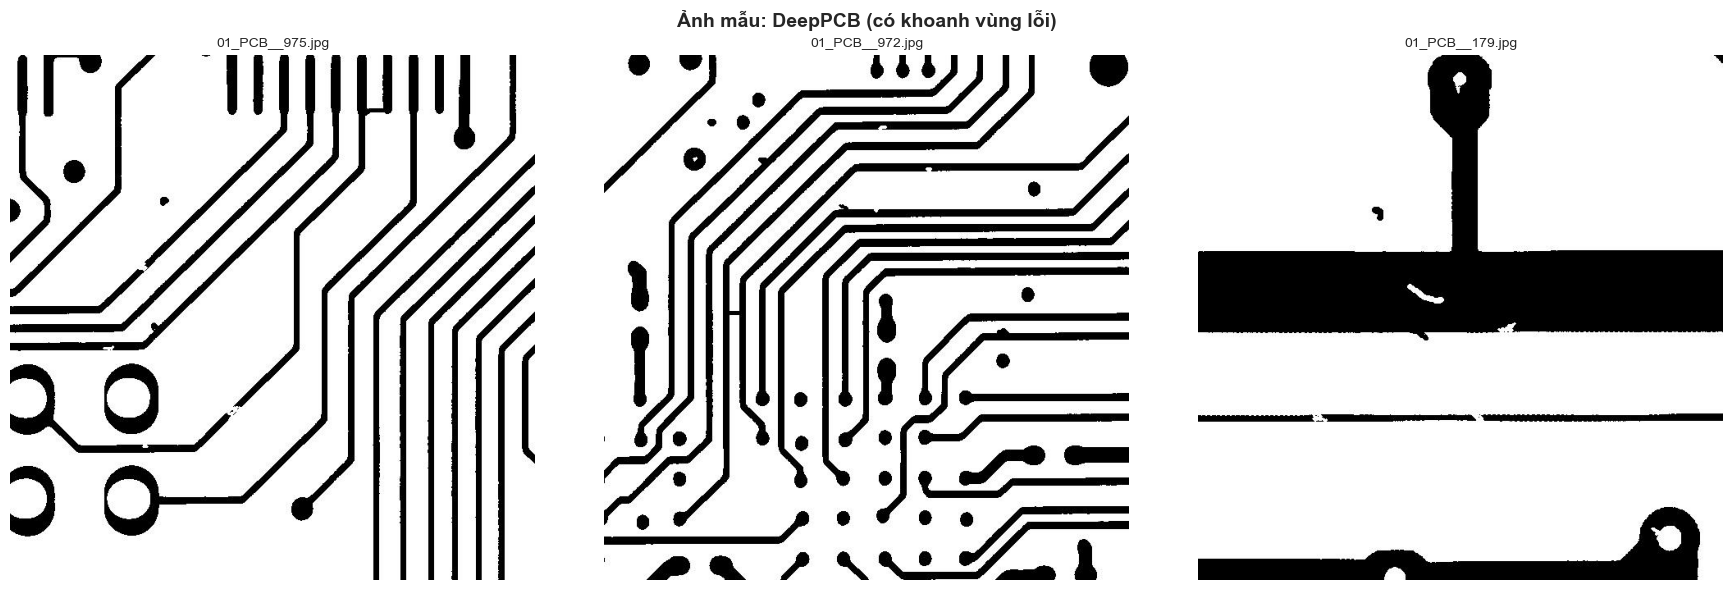

💾 Đã lưu: sample_DeepPCB.png

🖼️  Ảnh mẫu từ dataset: DsPCBSD+


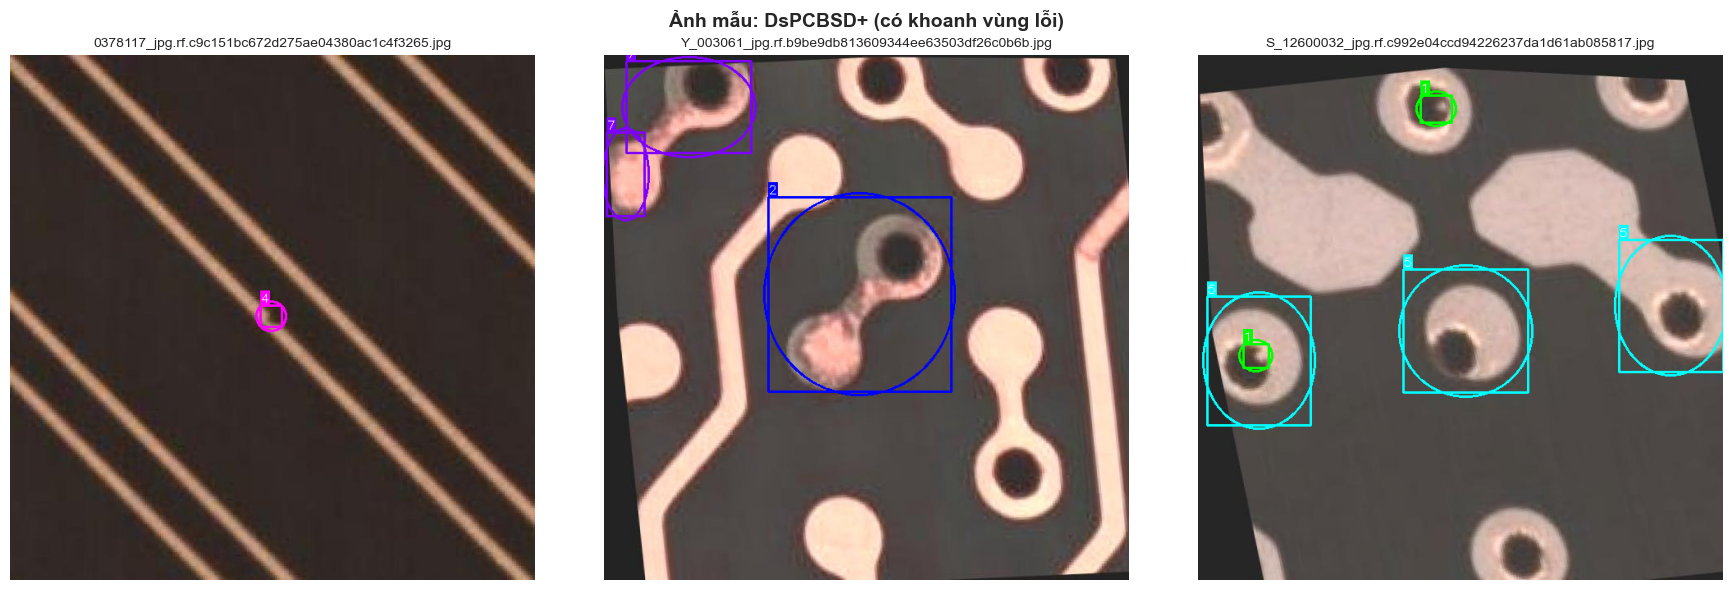

💾 Đã lưu: sample_DsPCBSD+.png


In [27]:
# ============================================================
# Hiển thị 3 ảnh mẫu từ mỗi dataset
# ============================================================
SO_ANH_MAU = 3

for name, info in DATASETS.items():
    print(f"\n{'='*60}")
    print(f"🖼️  Ảnh mẫu từ dataset: {name}")
    print(f"{'='*60}")
    
    train_img_dir = info['path'] / info['splits']['train'] / 'images'
    train_lbl_dir = info['path'] / info['splits']['train'] / 'labels'
    class_names = info.get('class_names', {})
    
    if not train_img_dir.exists():
        print(f"  ⚠️ Không tìm thấy thư mục: {train_img_dir}")
        continue
    
    # Lấy danh sách ảnh
    all_imgs = sorted([f for f in train_img_dir.iterdir() 
                       if f.is_file() and f.suffix.lower() in IMG_EXTENSIONS])
    
    # Chọn ngẫu nhiên
    sample_imgs = random.sample(all_imgs, min(SO_ANH_MAU, len(all_imgs)))
    
    fig, axes = plt.subplots(1, SO_ANH_MAU, figsize=(6*SO_ANH_MAU, 6))
    if SO_ANH_MAU == 1:
        axes = [axes]
    
    for i, img_file in enumerate(sample_imgs):
        lbl_file = train_lbl_dir / (img_file.stem + '.txt')
        img_with_bbox = ve_bbox_len_anh(img_file, lbl_file, class_names)
        
        if img_with_bbox is not None:
            axes[i].imshow(img_with_bbox)
            axes[i].set_title(f"{img_file.name}", fontsize=10)
        else:
            axes[i].set_title(f"❌ Lỗi đọc ảnh", fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle(f'Ảnh mẫu: {name} (có khoanh vùng lỗi)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(ROOT / f'sample_{name}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Đã lưu: sample_{name}.png')

## 7. Bảng mapping class names giữa 3 dataset

In [28]:
# ============================================================
# Tạo bảng mapping thống nhất class names
# ============================================================

# Mapping thủ công dựa trên ý nghĩa của từng class
# HRIPCB_UPDATE: {0: Missing_hole, 1: Mouse_bite, 2: Open_circuit, 3: Short, 4: Spurious_copper, 5: Spur}
# DeepPCB:       {0: copper, 1: mousebite, 2: open, 3: pin-hole, 4: short, 5: spur}
# DsPCBSD+:      {0-8: class 0 - class 8} → cần xác nhận thêm

mapping_data = [
    {'Loại lỗi chung': 'Missing Hole',     'HRIPCB_UPDATE (ID)': '0 - Missing_hole',     'DeepPCB (ID)': '3 - pin-hole',    'DsPCBSD+ (ID)': '? (cần xác nhận)'},
    {'Loại lỗi chung': 'Short',             'HRIPCB_UPDATE (ID)': '3 - Short',             'DeepPCB (ID)': '4 - short',        'DsPCBSD+ (ID)': '? (cần xác nhận)'},
    {'Loại lỗi chung': 'Open Circuit',      'HRIPCB_UPDATE (ID)': '2 - Open_circuit',      'DeepPCB (ID)': '2 - open',         'DsPCBSD+ (ID)': '? (cần xác nhận)'},
    {'Loại lỗi chung': 'Mouse Bite',        'HRIPCB_UPDATE (ID)': '1 - Mouse_bite',        'DeepPCB (ID)': '1 - mousebite',    'DsPCBSD+ (ID)': '? (cần xác nhận)'},
    {'Loại lỗi chung': 'Spur',              'HRIPCB_UPDATE (ID)': '5 - Spur',              'DeepPCB (ID)': '5 - spur',         'DsPCBSD+ (ID)': '? (cần xác nhận)'},
    {'Loại lỗi chung': 'Spurious Copper',   'HRIPCB_UPDATE (ID)': '4 - Spurious_copper',   'DeepPCB (ID)': '0 - copper',       'DsPCBSD+ (ID)': '? (cần xác nhận)'},
]

df_mapping = pd.DataFrame(mapping_data)

print('\n📋 BẢNG MAPPING CLASS NAMES GIỮA 3 DATASET')
print('='*80)
print('\n⚠️ Lưu ý: DsPCBSD+ có 9 class (0-8) với tên dạng số.')
print('  → Cần xem ảnh mẫu hoặc tài liệu gốc để xác nhận mapping.')
print()
display(df_mapping.style.set_properties(**{'text-align': 'center'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]))


📋 BẢNG MAPPING CLASS NAMES GIỮA 3 DATASET

⚠️ Lưu ý: DsPCBSD+ có 9 class (0-8) với tên dạng số.
  → Cần xem ảnh mẫu hoặc tài liệu gốc để xác nhận mapping.



,Loại lỗi chung,HRIPCB_UPDATE (ID),DeepPCB (ID),DsPCBSD+ (ID)
0,Missing Hole,0 - Missing_hole,3 - pin-hole,? (cần xác nhận)
1,Short,3 - Short,4 - short,? (cần xác nhận)
2,Open Circuit,2 - Open_circuit,2 - open,? (cần xác nhận)
3,Mouse Bite,1 - Mouse_bite,1 - mousebite,? (cần xác nhận)
4,Spur,5 - Spur,5 - spur,? (cần xác nhận)
5,Spurious Copper,4 - Spurious_copper,0 - copper,? (cần xác nhận)


In [29]:
# ============================================================
# Phân tích thêm: kích thước ảnh của mỗi dataset
# ============================================================
print('\n📏 THỐNG KÊ KÍCH THƯỚC ẢNH')
print('='*60)

for name, info in DATASETS.items():
    train_img_dir = info['path'] / info['splits']['train'] / 'images'
    
    if not train_img_dir.exists():
        continue
    
    all_imgs = [f for f in train_img_dir.iterdir() 
                if f.is_file() and f.suffix.lower() in IMG_EXTENSIONS]
    
    # Lấy mẫu (tối đa 50 ảnh) để thống kê nhanh
    sample = random.sample(all_imgs, min(50, len(all_imgs)))
    sizes = []
    for img_path in sample:
        img = cv2.imread(str(img_path))
        if img is not None:
            h, w = img.shape[:2]
            sizes.append((w, h))
    
    if sizes:
        widths = [s[0] for s in sizes]
        heights = [s[1] for s in sizes]
        print(f"\n📁 {name} (mẫu {len(sizes)} ảnh):")
        print(f"   Width  → Min: {min(widths)}, Max: {max(widths)}, Avg: {np.mean(widths):.0f}")
        print(f"   Height → Min: {min(heights)}, Max: {max(heights)}, Avg: {np.mean(heights):.0f}")
        
        # Kiểm tra kích thước đồng nhất
        if len(set(sizes)) == 1:
            print(f"   ✅ Tất cả ảnh cùng kích thước: {sizes[0][0]}x{sizes[0][1]}")
        else:
            print(f"   ⚠️ Kích thước ảnh KHÔNG đồng nhất ({len(set(sizes))} kích thước khác nhau)")


📏 THỐNG KÊ KÍCH THƯỚC ẢNH

📁 HRIPCB_UPDATE (mẫu 50 ảnh):
   Width  → Min: 2240, Max: 3056, Avg: 2803
   Height → Min: 1586, Max: 2530, Avg: 2142
   ⚠️ Kích thước ảnh KHÔNG đồng nhất (10 kích thước khác nhau)

📁 DeepPCB (mẫu 50 ảnh):
   Width  → Min: 640, Max: 640, Avg: 640
   Height → Min: 640, Max: 640, Avg: 640
   ✅ Tất cả ảnh cùng kích thước: 640x640

📁 DsPCBSD+ (mẫu 50 ảnh):
   Width  → Min: 640, Max: 640, Avg: 640
   Height → Min: 640, Max: 640, Avg: 640
   ✅ Tất cả ảnh cùng kích thước: 640x640


## 8. Tổng kết & Nhận xét

In [30]:
# ============================================================
# TỔNG KẾT BAN ĐẦU
# ============================================================
print('\n' + '='*60)
print('📊 TỔNG KẾT KHÁM PHÁ DỮ LIỆU')
print('='*60)

print('''
1. CÁC BỘ DỮ LIỆU:
   • HRIPCB_UPDATE: 6 class, có đầy đủ train/val/test
   • DeepPCB: 6 class, có đầy đủ train/val/test
   • DsPCBSD+: 9 class (tên dạng số), ban đầu KHÔNG có test
     → Đã tách 10% train thành test

2. CÁC LOẠI LỖI CHUNG:
   • Missing Hole (lỗ khoan thiếu)
   • Short (ngắn mạch)
   • Open Circuit (hở mạch)
   • Mouse Bite (gặm chuột)
   • Spur (gai)
   • Spurious Copper (đồng dư)

3. LƯU Ý:
   • Kiểm tra class imbalance ở biểu đồ phân bố nhãn
   • DsPCBSD+ có 9 class → cần xác nhận mapping với class chung
   • Cần chuẩn hóa kích thước ảnh nếu không đồng nhất

→ BƯỚC TIẾP THEO: Prompt 2 - Xử lý và chuẩn hóa dữ liệu
''')

print('\n🎉 HOÀN TẤT PROMPT 1 - IMPORT & KHÁM PHÁ DỮ LIỆU!')


📊 TỔNG KẾT KHÁM PHÁ DỮ LIỆU

1. CÁC BỘ DỮ LIỆU:
   • HRIPCB_UPDATE: 6 class, có đầy đủ train/val/test
   • DeepPCB: 6 class, có đầy đủ train/val/test
   • DsPCBSD+: 9 class (tên dạng số), ban đầu KHÔNG có test
     → Đã tách 10% train thành test

2. CÁC LOẠI LỖI CHUNG:
   • Missing Hole (lỗ khoan thiếu)
   • Short (ngắn mạch)
   • Open Circuit (hở mạch)
   • Mouse Bite (gặm chuột)
   • Spur (gai)
   • Spurious Copper (đồng dư)

3. LƯU Ý:
   • Kiểm tra class imbalance ở biểu đồ phân bố nhãn
   • DsPCBSD+ có 9 class → cần xác nhận mapping với class chung
   • Cần chuẩn hóa kích thước ảnh nếu không đồng nhất

→ BƯỚC TIẾP THEO: Prompt 2 - Xử lý và chuẩn hóa dữ liệu


🎉 HOÀN TẤT PROMPT 1 - IMPORT & KHÁM PHÁ DỮ LIỆU!
